In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [27]:
df = pd.read_csv("earthquake_data_tsunami.csv")
df.head()


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [29]:
df.describe()  #Numerical Columns

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [30]:
df.isnull().sum()

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

In [31]:
df.columns = df.columns.str.lower()

In [32]:
df.columns

Index(['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude', 'year', 'month', 'tsunami'],
      dtype='object')

**1) Time-Based Analysis:**

**Explore how earthquake occurrences and tsunami events have changed over the 22-year period (2001–2022).**

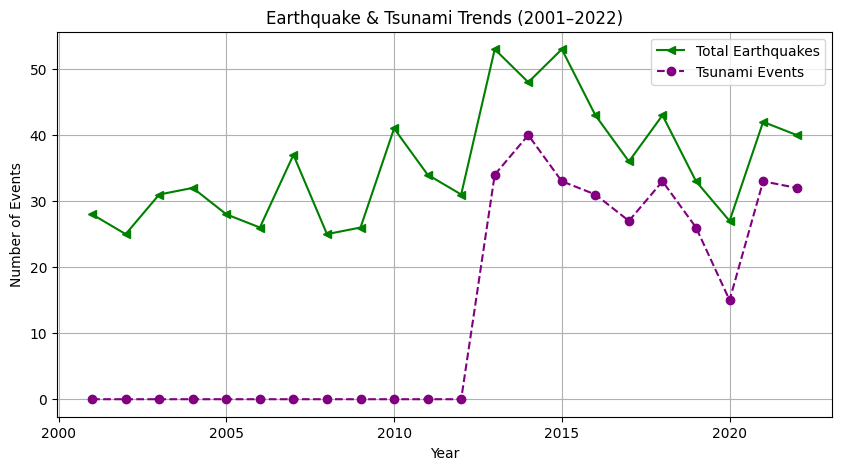

In [52]:
# Group earthquake counts per year
earthquake_count = df.groupby('Year').size()

# Group tsunami events per year (sum of 1s and 0s)
tsunami_count = da.groupby('Year')['tsunami'].sum()

# Plot directly using those grouped results
plt.figure(figsize=(10,5))
plt.plot(earthquake_count.index, earthquake_count.values, 
         marker='<', linestyle='-', color='green', label='Total Earthquakes')

plt.plot(tsunami_count.index, tsunami_count.values, 
         marker='o', linestyle='--', color='purple', label='Tsunami Events')

plt.title("Earthquake & Tsunami Trends (2001–2022)")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.legend()
plt.grid(True)
plt.show()


**Identify any trends in the frequency or magnitude of earthquakes over time.**

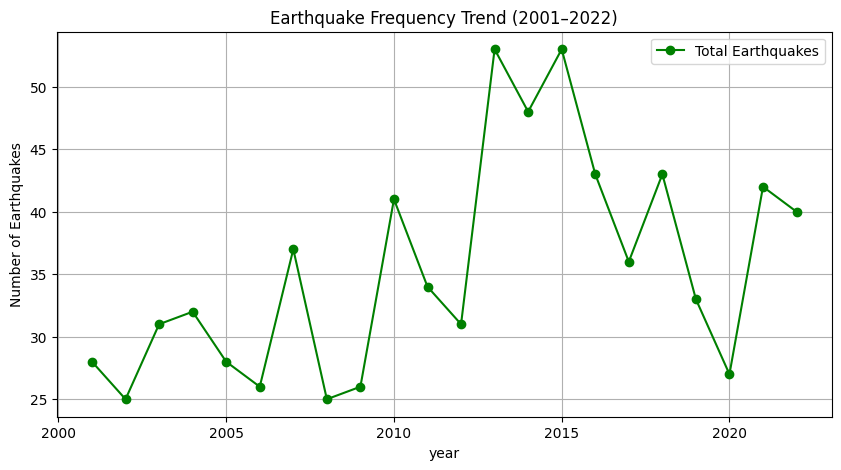

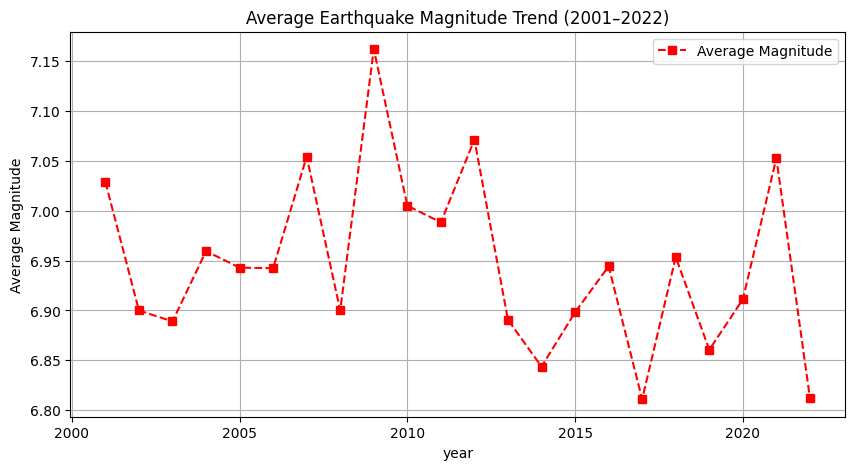

In [33]:
# Group by year to calculate total earthquakes and average magnitude
yearly_data = df.groupby('year').agg({
    'magnitude': 'mean'
}).reset_index()

# Add total earthquake count
yearly_data['Earthquake_Count'] = df.groupby('year').size().values

# Plot 1:c Earthquake Frequency Over Time
plt.figure(figsize=(10,5))
plt.plot(yearly_data['year'], yearly_data['Earthquake_Count'], marker='o', color='green', label='Total Earthquakes')
plt.title("Earthquake Frequency Trend (2001–2022)")
plt.xlabel("year")
plt.ylabel("Number of Earthquakes")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Average Magnitude Over Time
plt.figure(figsize=(10,5))
plt.plot(yearly_data['year'], yearly_data['magnitude'], marker='s', linestyle='--', color='red', label='Average Magnitude')
plt.title("Average Earthquake Magnitude Trend (2001–2022)")
plt.xlabel("year")
plt.ylabel("Average Magnitude")
plt.legend()
plt.grid(True)
plt.show()

**2) Magnitude and Depth Analysis:**

**Analyze the distribution of earthquake magnitudes and depths.**

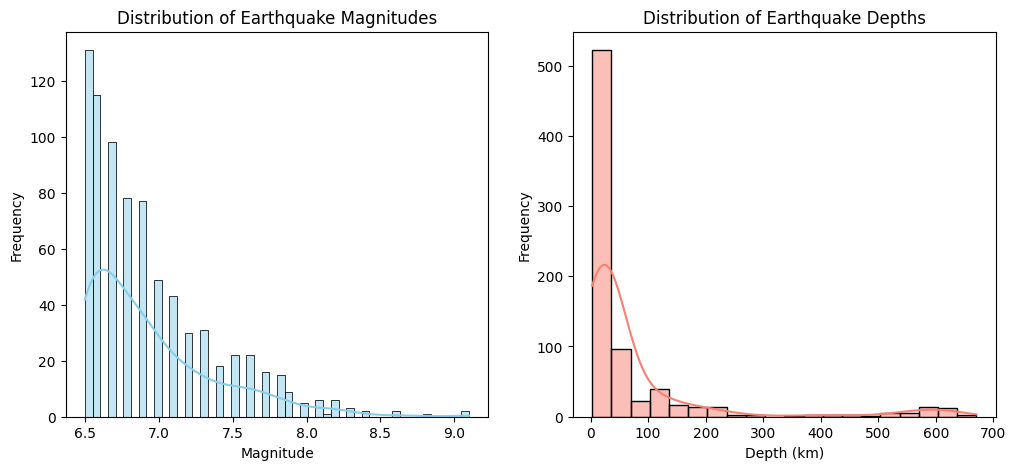

In [34]:
# Plot the distribution of Magnitude and Depth
plt.figure(figsize=(12,5))

# Magnitude distribution
plt.subplot(1,2,1)
sns.histplot(df['magnitude'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')

# Depth distribution
plt.subplot(1,2,2)
sns.histplot(df['depth'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Earthquake Depths')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')

plt.show()

**Compare the average magnitude and depth of tsunami vs. non-tsunami events.**

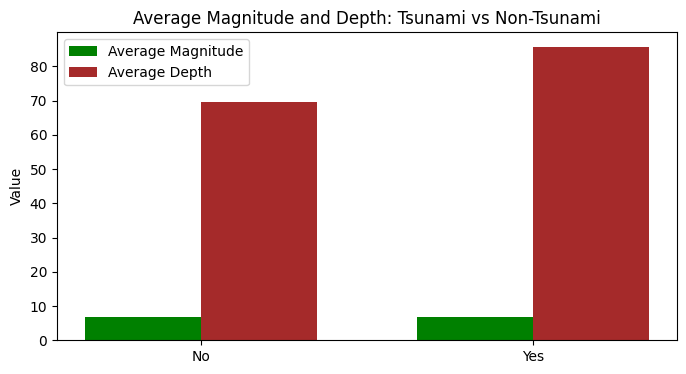

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by tsunami (0 = No, 1 = Yes) and calculate mean
avg_stats = df.groupby('tsunami')[['magnitude','depth']].mean().reset_index()
avg_stats['Tsunami'] = avg_stats['tsunami'].map({0:'No', 1:'Yes'})

# Plotting
plt.figure(figsize=(8,4))
bar_width = 0.35
x = range(len(avg_stats))

# Average Magnitude
plt.bar(x, avg_stats['magnitude'], width=bar_width, label='Average Magnitude', color='green')

# Average Depth
plt.bar([i + bar_width for i in x], avg_stats['depth'], width=bar_width, label='Average Depth', color='Brown')

# X-axis labels
plt.xticks([i + bar_width/2 for i in x], avg_stats['Tsunami'])
plt.ylabel('Value')
plt.title('Average Magnitude and Depth: Tsunami vs Non-Tsunami')
plt.legend()
plt.show()

**Highlight major earthquakes (≥8.0) and their characteristics.**

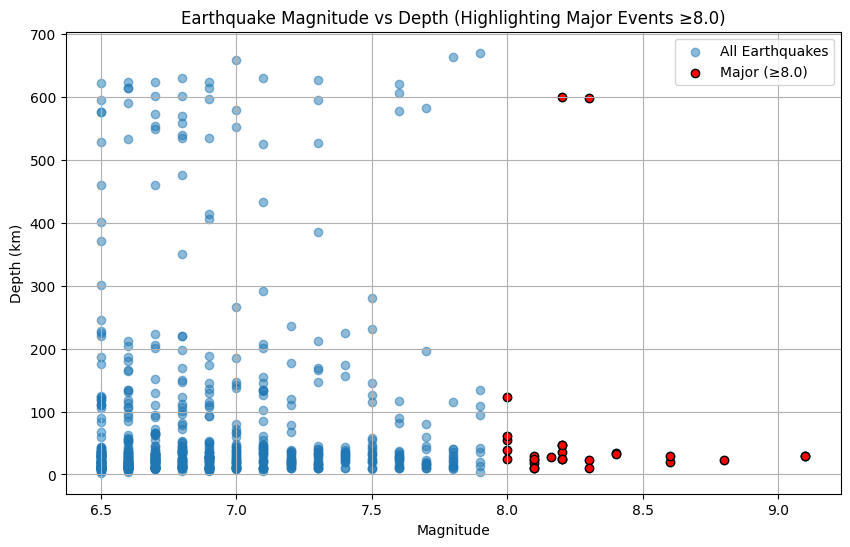

In [36]:
major_eq = df[df['magnitude'] >= 8.0]

plt.figure(figsize=(10,6))
plt.scatter(df['magnitude'], df['depth'], alpha=0.5, label='All Earthquakes')
plt.scatter(major_eq['magnitude'], major_eq['depth'], color='red', label='Major (≥8.0)', edgecolor='black')

plt.title("Earthquake Magnitude vs Depth (Highlighting Major Events ≥8.0)")
plt.xlabel("Magnitude")
plt.ylabel("Depth (km)")
plt.legend()
plt.grid(True)
plt.show()


**3)Geographic Distribution Using 2D Plotting:**

**Plot earthquake locations using latitude and longitude on a 2D scatter plot.**

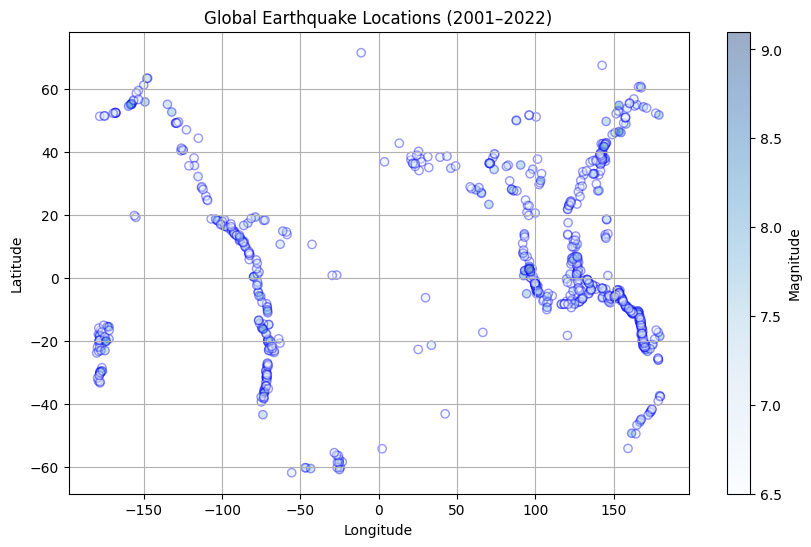

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(
    df['longitude'], df['latitude'],alpha=0.4,c=df['magnitude'],cmap='Blues',edgecolor='b'
)
plt.title("Global Earthquake Locations (2001–2022)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label='Magnitude')
plt.grid(True)
plt.show()

**Visually distinguish between tsunami and non-tsunami events.**

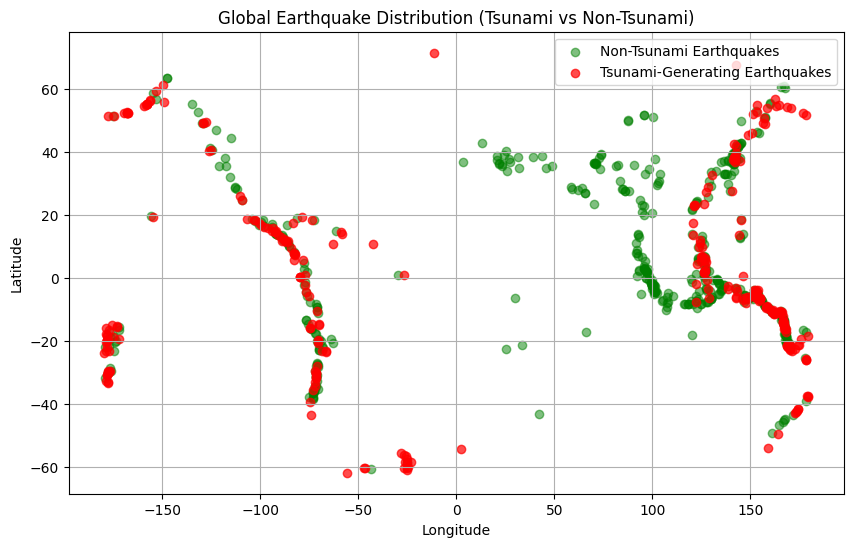

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("earthquake_data_tsunami.csv")

plt.figure(figsize=(10,6))

plt.scatter(df[df['tsunami'] == 0]['longitude'],
            df[df['tsunami'] == 0]['latitude'],
            color='green', alpha=0.5, label='Non-Tsunami Earthquakes')

plt.scatter(df[df['tsunami'] == 1]['longitude'],
            df[df['tsunami'] == 1]['latitude'],
            color='red', alpha=0.7, label='Tsunami-Generating Earthquakes')

plt.title("Global Earthquake Distribution (Tsunami vs Non-Tsunami)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

**Identify clusters or regions with higher concentration of tsunami events (without using map tiles or interactive maps).**

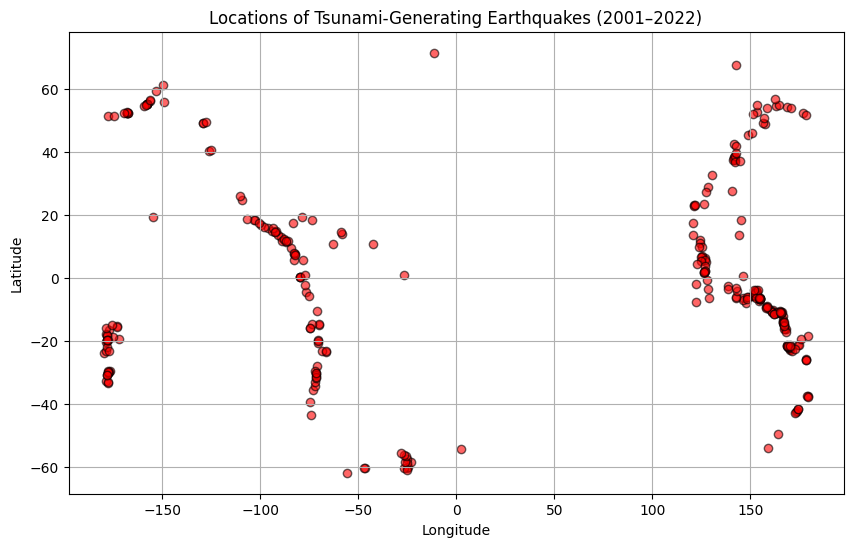

In [43]:
plt.figure(figsize=(10,6))
plt.scatter(
    df[df['tsunami'] == 1]['longitude'],   # filter directly for tsunami events
    df[df['tsunami'] == 1]['latitude'],
    color='red', alpha=0.6, edgecolor='black'
)
plt.title("Locations of Tsunami-Generating Earthquakes (2001–2022)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

**4) Statistical and Comparative Analysis:**

**Use box plots, histograms, and bar chart to compare seismic features between tsunami and non-tsunami events.**

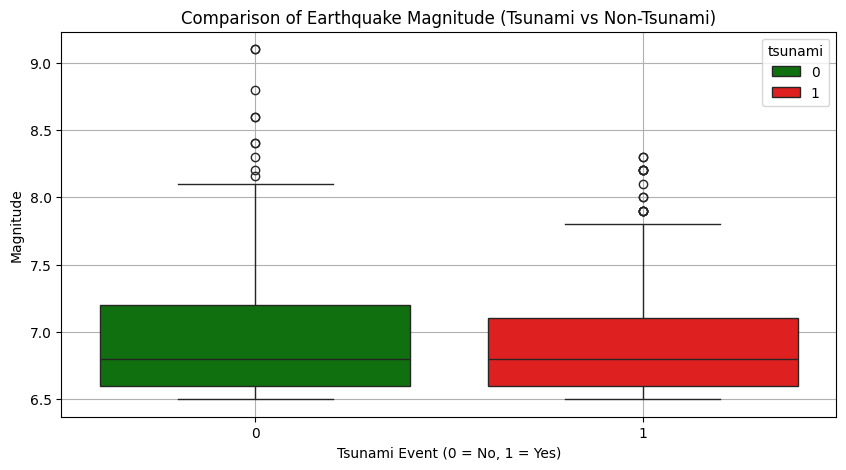

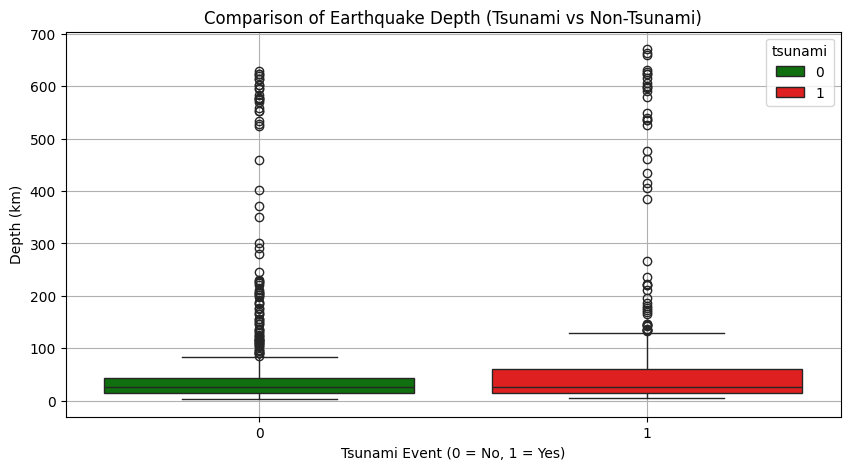

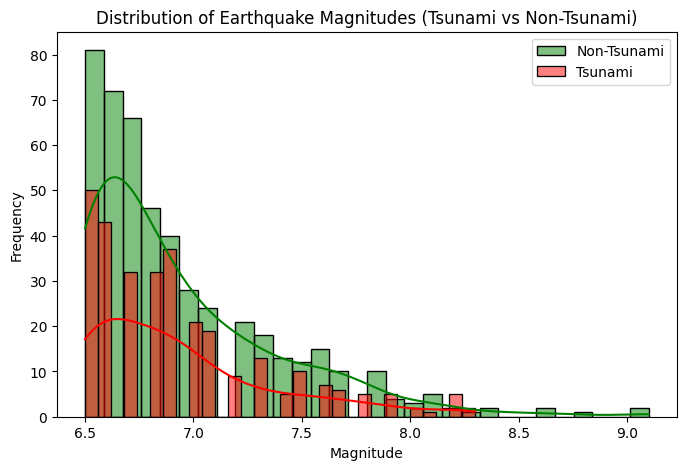

In [44]:
plt.figure(figsize=(10,5))

# Boxplot for Magnitude
sns.boxplot(x='tsunami', y='magnitude',hue='tsunami', data=df, palette=['green', 'red'])
plt.title("Comparison of Earthquake Magnitude (Tsunami vs Non-Tsunami)")
plt.xlabel("Tsunami Event (0 = No, 1 = Yes)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()


# Boxplot for Depth
plt.figure(figsize=(10,5))
sns.boxplot(x='tsunami', y='depth',hue='tsunami', data=df, palette=['green', 'red'])
plt.title("Comparison of Earthquake Depth (Tsunami vs Non-Tsunami)")
plt.xlabel("Tsunami Event (0 = No, 1 = Yes)")
plt.ylabel("Depth (km)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df[df['tsunami']==0]['magnitude'], bins=30, color='green', label='Non-Tsunami', kde=True)
sns.histplot(df[df['tsunami']==1]['magnitude'], bins=30, color='red', label='Tsunami', kde=True)
plt.title("Distribution of Earthquake Magnitudes (Tsunami vs Non-Tsunami)")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.legend()
plt.show()


**Analyze correlations between variables using heatmaps.**

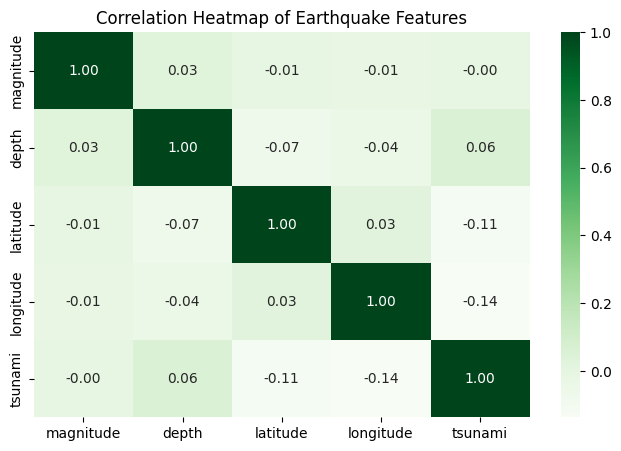

In [45]:
# Select only numeric columns for correlation
numeric_data = df[['magnitude', 'depth', 'latitude', 'longitude', 'tsunami']]

# Compute correlation matrix
corr = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='Greens', fmt='.2f')

plt.title("Correlation Heatmap of Earthquake Features")
plt.show()

**5) Insights and Observations**